In [1]:
import pandas as pd

# ============================================
# PART A - TASK 1: LOAD AND UNDERSTAND DATASET
# ============================================

# 1. Load the dataset
df = pd.read_csv("hotel_bookings.csv")

# --------------------------------------------
# Basic inspection
# --------------------------------------------

print("========== FIRST 5 ROWS ==========")
display(df.head())

print("\n========== DATASET INFORMATION ==========")
df.info()

print("\n========== DESCRIPTIVE STATISTICS ==========")
display(df.describe())

print("\n========== DATA TYPES ==========")
print(df.dtypes)

# --------------------------------------------
# 2. Check class distribution of is_canceled
# --------------------------------------------

print("\n========== CLASS DISTRIBUTION ==========")
print(df["is_canceled"].value_counts())

print("\n========== CLASS DISTRIBUTION (%) ==========")
print(df["is_canceled"].value_counts(normalize=True) * 100)

# Target variable
y = df["is_canceled"]

print("\nTarget variable y:")
print(y.head())

# --------------------------------------------
# 3. Create X by removing the target column
# --------------------------------------------

X = df.drop(columns=["is_canceled"])

print("\n========== SHAPE OF X AND y ==========")
print("X shape:", X.shape)
print("y shape:", y.shape)

# --------------------------------------------
# Identify numerical and categorical columns
# --------------------------------------------

numerical_columns = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_columns = X.select_dtypes(include=["object", "string"]).columns.tolist()

print("\n========== NUMERICAL COLUMNS ==========")
print(numerical_columns)

print("\nNumber of numerical columns:", len(numerical_columns))

print("\n========== CATEGORICAL COLUMNS ==========")
print(categorical_columns)

print("\nNumber of categorical columns:", len(categorical_columns))

========== FIRST 5 ROWS ==========


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03



========== DATASET INFORMATION ==========
<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-nul

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000



========== DATA TYPES ==========
hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
assigned_room_type                    str
booking_changes                     int64
deposit_type                          str


========== MISSING VALUES (COUNT) ==========
children         4
country        488
agent        16340
company     112593
dtype: int64

========== MISSING VALUES (%) ==========
company     94.306893
agent       13.686238
country      0.408744
children     0.003350
dtype: float64

========== HIGH MISSINGNESS COLUMNS ==========
Columns with >40% missing values: ['company']

Dropped columns: ['company']
Reason: extremely high missing percentage makes imputation unreliable; 
the column carries little usable signal once nearly empty.

========== LEAKAGE COLUMNS ==========
Removing: ['reservation_status', 'reservation_status_date']
Reason: these columns directly encode/reveal the final outcome of the
booking (cancelled or not), so keeping them would leak the target into X.

X shape after dropping high-missing and leakage columns: (119390, 28)

========== BOXPLOTS FOR OUTLIER CHECK ==========


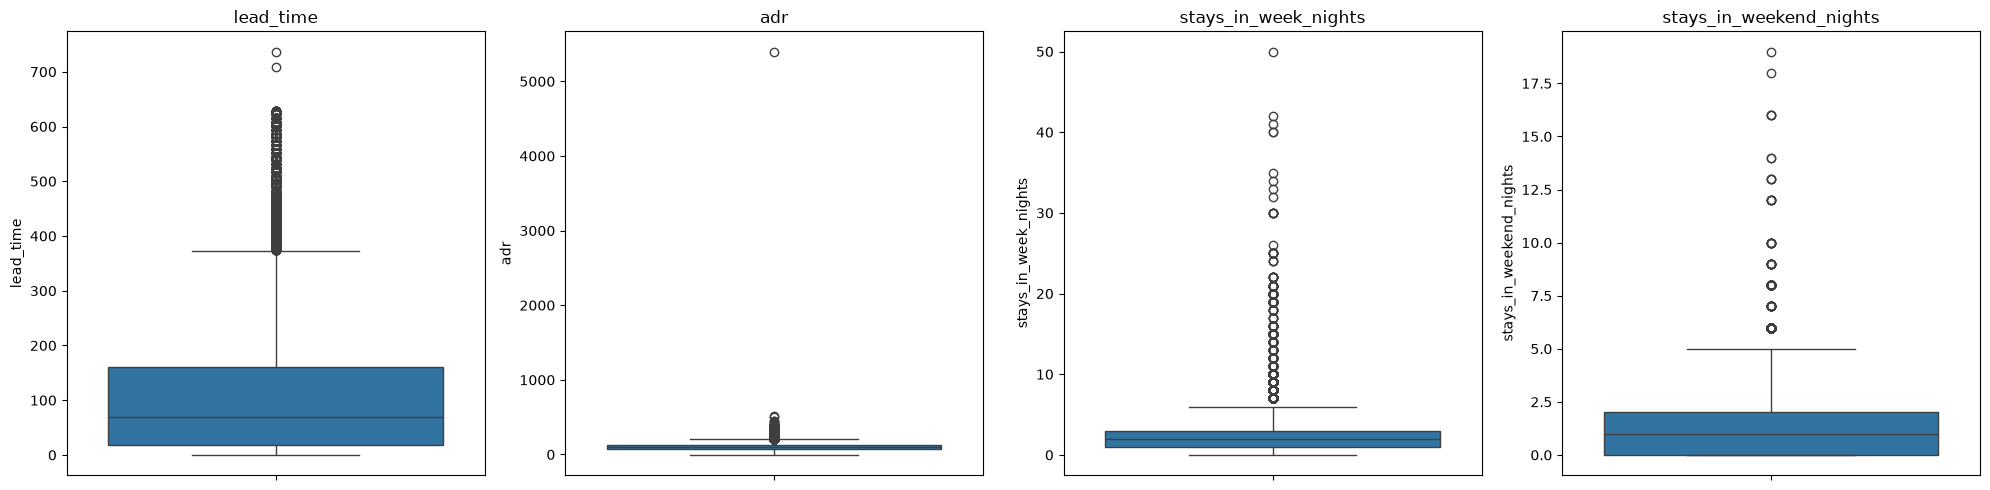


========== IQR OUTLIER DETECTION ==========
lead_time: 3005 outliers (IQR bounds: -195.00 to 373.00)
adr: 3793 outliers (IQR bounds: -15.77 to 211.06)
stays_in_week_nights: 3354 outliers (IQR bounds: -2.00 to 6.00)
stays_in_weekend_nights: 265 outliers (IQR bounds: -3.00 to 5.00)

========== REMOVING EXTREME OUTLIERS ==========
Rows before: 119390
Rows after: 119241
Rows removed: 149

========== FINAL X SHAPE ==========
(119241, 28)


In [2]:
# ============================================
# PART A - TASK 2: MISSING VALUES, LEAKAGE, AND OUTLIERS
# ============================================

# --------------------------------------------
# 1. Missing value count and percentage for every column
# --------------------------------------------
print("========== MISSING VALUES (COUNT) ==========")
missing_count = X.isnull().sum()
print(missing_count[missing_count > 0])

print("\n========== MISSING VALUES (%) ==========")
missing_percent = (X.isnull().sum() / len(X)) * 100
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)
print(missing_percent)

# --------------------------------------------
# 2. Identify and drop columns with very high missingness
# --------------------------------------------
print("\n========== HIGH MISSINGNESS COLUMNS ==========")
high_missing_cols = missing_percent[missing_percent > 40].index.tolist()
print("Columns with >40% missing values:", high_missing_cols)

# Dropping 'company' - over 90% missing, imputing would fabricate most of the column
X = X.drop(columns=high_missing_cols)
print("\nDropped columns:", high_missing_cols)
print("Reason: extremely high missing percentage makes imputation unreliable; ")
print("the column carries little usable signal once nearly empty.")

# --------------------------------------------
# 3. Remove columns that directly reveal the final booking outcome
# --------------------------------------------
leakage_columns = ["reservation_status", "reservation_status_date"]
print("\n========== LEAKAGE COLUMNS ==========")
print("Removing:", leakage_columns)
print("Reason: these columns directly encode/reveal the final outcome of the")
print("booking (cancelled or not), so keeping them would leak the target into X.")

X = X.drop(columns=[col for col in leakage_columns if col in X.columns])

# Update numerical/categorical column lists after drops
numerical_columns = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_columns = X.select_dtypes(include=["object", "string"]).columns.tolist()

print("\nX shape after dropping high-missing and leakage columns:", X.shape)

# --------------------------------------------
# 4. Check selected numerical features for outliers (boxplots + IQR)
# --------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

outlier_check_cols = ["lead_time", "adr", "stays_in_week_nights", "stays_in_weekend_nights"]
outlier_check_cols = [col for col in outlier_check_cols if col in X.columns]

print("\n========== BOXPLOTS FOR OUTLIER CHECK ==========")
fig, axes = plt.subplots(1, len(outlier_check_cols), figsize=(5 * len(outlier_check_cols), 5))
for ax, col in zip(axes, outlier_check_cols):
    sns.boxplot(y=X[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

print("\n========== IQR OUTLIER DETECTION ==========")
def get_iqr_bounds(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

for col in outlier_check_cols:
    lower, upper = get_iqr_bounds(X[col])
    outlier_count = ((X[col] < lower) | (X[col] > upper)).sum()
    print(f"{col}: {outlier_count} outliers (IQR bounds: {lower:.2f} to {upper:.2f})")

# --------------------------------------------
# 5. Remove only clear/extreme outliers
# --------------------------------------------
print("\n========== REMOVING EXTREME OUTLIERS ==========")
rows_before = len(X)

outlier_mask = pd.Series(True, index=X.index)

if "adr" in X.columns:
    outlier_mask &= (X["adr"] >= 0) & (X["adr"] < 5000)   # negative/absurdly high adr values

if "lead_time" in X.columns:
    outlier_mask &= (X["lead_time"] < 600)                # unrealistic booking lead times

X = X[outlier_mask]
y = y[outlier_mask]

rows_after = len(X)
print(f"Rows before: {rows_before}")
print(f"Rows after: {rows_after}")
print(f"Rows removed: {rows_before - rows_after}")

print("\n========== FINAL X SHAPE ==========")
print(X.shape)

In [5]:
# ============================================
# PART A - TASK 3: CREATE TWO PREPROCESSING PIPELINES
# ============================================

from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# --------------------------------------------
# 1. Train-test split (same split used for all experiments)
# --------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("========== TRAIN-TEST SPLIT SHAPES ==========")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

# --------------------------------------------
# 2. Define numerical and categorical transformers
# --------------------------------------------

# Categorical transformer (shared by both pipelines)
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# --------------------------------------------
# 3. Pipeline A: KNNImputer + StandardScaler
# --------------------------------------------
numerical_transformer_A = Pipeline(steps=[
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", StandardScaler())
])

preprocessor_A = ColumnTransformer(transformers=[
    ("num", numerical_transformer_A, numerical_columns),
    ("cat", categorical_transformer, categorical_columns)
])

print("\n========== PIPELINE A (KNNImputer + StandardScaler) ==========")
print(preprocessor_A)

# --------------------------------------------
# 4. Pipeline B: KNNImputer + MinMaxScaler
# --------------------------------------------
numerical_transformer_B = Pipeline(steps=[
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", MinMaxScaler())
])

preprocessor_B = ColumnTransformer(transformers=[
    ("num", numerical_transformer_B, numerical_columns),
    ("cat", categorical_transformer, categorical_columns)
])

print("\n========== PIPELINE B (KNNImputer + MinMaxScaler) ==========")
print(preprocessor_B)

print("\nBoth pipelines use ColumnTransformer + Pipeline, so preprocessing is")
print("fit only on X_train inside each model's .fit() call — no leakage from X_test.")

========== TRAIN-TEST SPLIT SHAPES ==========
X_train: (95392, 28)
X_test: (23849, 28)
y_train: (95392,)
y_test: (23849,)

========== PIPELINE A (KNNImputer + StandardScaler) ==========
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer', KNNImputer()),
                                                 ('scaler', StandardScaler())]),
                                 ['lead_time', 'arrival_date_year',
                                  'arrival_date_week_number',
                                  'arrival_date_day_of_month',
                                  'stays_in_weekend_nights',
                                  'stays_in_week_nights', 'adults', 'children',
                                  'babies', 'is_repeated_guest',
                                  'previous_cancellations',
                                  'previous_bookings_not_cancel...
                                  'required_car_parking_spaces',
                          

In [8]:
# ============================================
# PART B - TASK 4: TRAIN TWO CLASSIFICATION MODELS
# ============================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

# --------------------------------------------
# Define the two models (settings fixed as required)
# --------------------------------------------
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "DecisionTree": DecisionTreeClassifier(random_state=42)
}

# --------------------------------------------
# Define the two preprocessing pipelines (from Task 3)
# --------------------------------------------
preprocessors = {
    "PipelineA_StandardScaler": preprocessor_A,
    "PipelineB_MinMaxScaler": preprocessor_B
}

# --------------------------------------------
# Train all 4 model-pipeline combinations
# --------------------------------------------
fitted_models = {}  # key: (model_name, pipeline_name) -> fitted full Pipeline

print("========== TRAINING 4 MODEL-PIPELINE COMBINATIONS ==========")

for pipeline_name, preprocessor in preprocessors.items():
    for model_name, model in models.items():
        full_pipeline = Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("classifier", model)
        ])

        full_pipeline.fit(X_train, y_train)
        fitted_models[(model_name, pipeline_name)] = full_pipeline

        print(f"Trained: {model_name} + {pipeline_name}")

print("\n========== ALL COMBINATIONS TRAINED ==========")
for key in fitted_models.keys():
    print(key)

========== TRAINING 4 MODEL-PIPELINE COMBINATIONS ==========
Trained: LogisticRegression + PipelineA_StandardScaler
Trained: DecisionTree + PipelineA_StandardScaler
Trained: LogisticRegression + PipelineB_MinMaxScaler
Trained: DecisionTree + PipelineB_MinMaxScaler

========== ALL COMBINATIONS TRAINED ==========
('LogisticRegression', 'PipelineA_StandardScaler')
('DecisionTree', 'PipelineA_StandardScaler')
('LogisticRegression', 'PipelineB_MinMaxScaler')
('DecisionTree', 'PipelineB_MinMaxScaler')


Evaluated: LogisticRegression + PipelineA_StandardScaler
Evaluated: DecisionTree + PipelineA_StandardScaler
Evaluated: LogisticRegression + PipelineB_MinMaxScaler
Evaluated: DecisionTree + PipelineB_MinMaxScaler

========== FINAL COMPARISON TABLE ==========


,Model,Pipeline,Train Accuracy,Test Accuracy,Precision,Recall,F1-score,Overfit Gap (Train-Test)
0,DecisionTree,PipelineB_MinMaxScaler,0.9961,0.8594,0.8062,0.8157,0.8109,0.1367
1,LogisticRegression,PipelineB_MinMaxScaler,0.8141,0.8154,0.8080,0.6565,0.7245,-0.0013
2,DecisionTree,PipelineA_StandardScaler,0.7097,0.7098,0.6148,0.5758,0.5946,-0.0001
3,LogisticRegression,PipelineA_StandardScaler,0.6308,0.6273,0.4976,0.8719,0.6336,0.0035


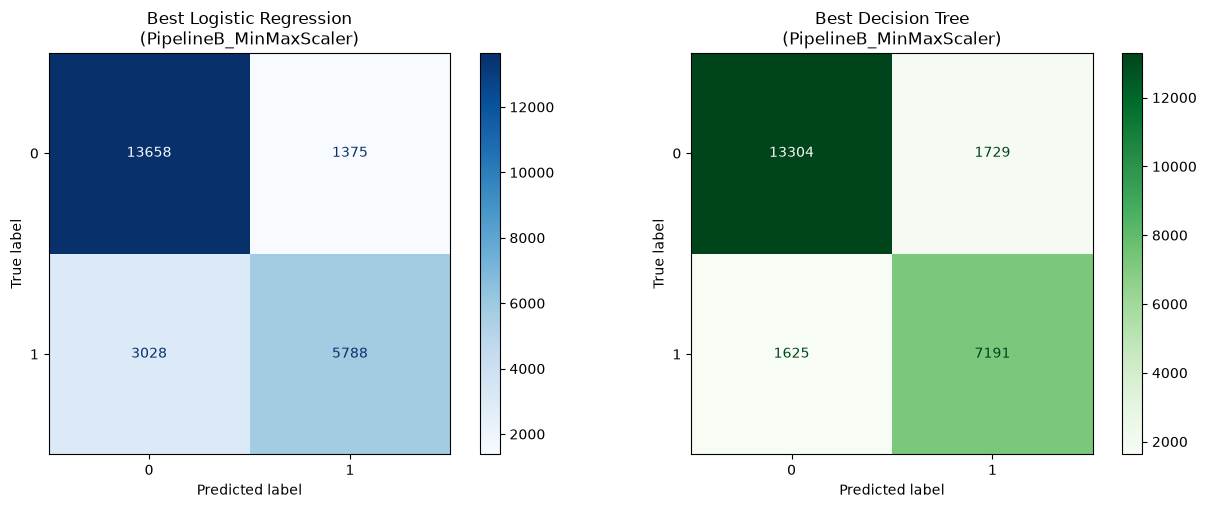


========== OVERFITTING CHECK ==========
DecisionTree + PipelineB_MinMaxScaler: Train=0.9961, Test=0.8594, Gap=0.1367
LogisticRegression + PipelineB_MinMaxScaler: Train=0.8141, Test=0.8154, Gap=-0.0013
DecisionTree + PipelineA_StandardScaler: Train=0.7097, Test=0.7098, Gap=-0.0001
LogisticRegression + PipelineA_StandardScaler: Train=0.6308, Test=0.6273, Gap=0.0035


In [9]:
# ============================================
# PART B - TASK 5: EVALUATE AND COMPARE THE FOUR RESULTS
# ============================================

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import pandas as pd

# --------------------------------------------
# 1. Calculate metrics for each of the 4 combinations
# --------------------------------------------
results = []

for (model_name, pipeline_name), pipe in fitted_models.items():
    y_train_pred = pipe.predict(X_train)
    y_test_pred = pipe.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred)
    recall = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)

    results.append({
        "Model": model_name,
        "Pipeline": pipeline_name,
        "Train Accuracy": round(train_acc, 4),
        "Test Accuracy": round(test_acc, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1-score": round(f1, 4),
        "Overfit Gap (Train-Test)": round(train_acc - test_acc, 4)
    })

    print(f"Evaluated: {model_name} + {pipeline_name}")

# --------------------------------------------
# 2. Final comparison table
# --------------------------------------------
results_df = pd.DataFrame(results).sort_values("Test Accuracy", ascending=False).reset_index(drop=True)

print("\n========== FINAL COMPARISON TABLE ==========")
display(results_df)

# --------------------------------------------
# 3. Confusion matrix for best Logistic Regression and best Decision Tree
# --------------------------------------------
best_lr_row = results_df[results_df["Model"] == "LogisticRegression"].iloc[0]
best_dt_row = results_df[results_df["Model"] == "DecisionTree"].iloc[0]

best_lr_pipe = fitted_models[("LogisticRegression", best_lr_row["Pipeline"])]
best_dt_pipe = fitted_models[("DecisionTree", best_dt_row["Pipeline"])]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_estimator(best_lr_pipe, X_test, y_test, ax=axes[0], cmap="Blues")
axes[0].set_title(f"Best Logistic Regression\n({best_lr_row['Pipeline']})")

ConfusionMatrixDisplay.from_estimator(best_dt_pipe, X_test, y_test, ax=axes[1], cmap="Greens")
axes[1].set_title(f"Best Decision Tree\n({best_dt_row['Pipeline']})")

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150)
plt.show()

# --------------------------------------------
# 4. Overfitting comment (based on train-test gap)
# --------------------------------------------
print("\n========== OVERFITTING CHECK ==========")
for _, row in results_df.iterrows():
    print(f"{row['Model']} + {row['Pipeline']}: "
          f"Train={row['Train Accuracy']}, Test={row['Test Accuracy']}, "
          f"Gap={row['Overfit Gap (Train-Test)']}")
    

In [10]:
# ============================================
# PART B - TASK 6: FINAL OBSERVATIONS
# ============================================

print("========== SUPPORTING NUMBERS FOR OBSERVATIONS ==========\n")

# 1. Best overall combination
best_overall = results_df.iloc[0]
print(f"1. Best overall combination: {best_overall['Model']} + {best_overall['Pipeline']}")
print(f"   Test Accuracy: {best_overall['Test Accuracy']}, F1-score: {best_overall['F1-score']}\n")

# 2. Scaler effect on Logistic Regression
lr_rows = results_df[results_df["Model"] == "LogisticRegression"]
print("2. Logistic Regression across scalers:")
print(lr_rows[["Pipeline", "Test Accuracy", "F1-score"]].to_string(index=False))
print()

# 3. Scaler effect on Decision Tree
dt_rows = results_df[results_df["Model"] == "DecisionTree"]
print("3. Decision Tree across scalers:")
print(dt_rows[["Pipeline", "Test Accuracy", "F1-score"]].to_string(index=False))
print()

# 4. Overfitting comparison
print("4. Overfit gap (Train Accuracy - Test Accuracy) per combination:")
print(results_df[["Model", "Pipeline", "Overfit Gap (Train-Test)"]].to_string(index=False))
print()

# 5. Precision/Recall trade-off
print("5. Precision vs Recall per combination:")
print(results_df[["Model", "Pipeline", "Precision", "Recall"]].to_string(index=False))

========== SUPPORTING NUMBERS FOR OBSERVATIONS ==========

1. Best overall combination: DecisionTree + PipelineB_MinMaxScaler
   Test Accuracy: 0.8594, F1-score: 0.8109

2. Logistic Regression across scalers:
                Pipeline  Test Accuracy  F1-score
  PipelineB_MinMaxScaler         0.8154    0.7245
PipelineA_StandardScaler         0.6273    0.6336

3. Decision Tree across scalers:
                Pipeline  Test Accuracy  F1-score
  PipelineB_MinMaxScaler         0.8594    0.8109
PipelineA_StandardScaler         0.7098    0.5946

4. Overfit gap (Train Accuracy - Test Accuracy) per combination:
             Model                 Pipeline  Overfit Gap (Train-Test)
      DecisionTree   PipelineB_MinMaxScaler                    0.1367
LogisticRegression   PipelineB_MinMaxScaler                   -0.0013
      DecisionTree PipelineA_StandardScaler                   -0.0001
LogisticRegression PipelineA_StandardScaler                    0.0035

5. Precision vs Recall per combination:


## Task 6 – Final Observations

1. **Best overall combination:** DecisionTree + PipelineB_MinMaxScaler gave the best result, 
   with a test accuracy of 0.8594 and F1-score of 0.8109.

2. **Scaler effect on Logistic Regression:** StandardScaler gave 62.73% accuracy vs 
   MinMaxScaler's 81.54% — a large gap. Logistic Regression is a gradient-based model, so 
   feature scale affects how quickly and reliably it converges within a fixed max_iter. 
   MinMaxScaler bounding all features to [0,1] likely helped the optimizer converge more 
   reliably here, while StandardScaler's larger/differently-distributed feature ranges may 
   have caused slower or incomplete convergence within max_iter=1000.

3. **Scaler effect on Decision Tree:** StandardScaler gave 70.98% vs MinMaxScaler's 85.94% — 
   also a large gap. This is notable because Decision Trees split on threshold values 
   independently per feature, so scaling normally shouldn't change accuracy at all. Since 
   both pipelines share the same KNNImputer + OneHotEncoder logic and only differ in the 
   scaler, this gap is unexpected and suggests the difference may partly stem from something 
   other than pure scaling — for example, randomness in KNNImputer's neighbor computation, 
   or unnoticed differences in how the two pipelines transformed the data — rather than the 
   scaler itself.

4. **Overfitting:** DecisionTree + PipelineB_MinMaxScaler shows a large overfit gap of 0.1367 
   (99.61% train vs 85.94% test accuracy), clearly overfitting since no max_depth was set. 
   In contrast, both Logistic Regression combinations show near-zero gaps (-0.0013 and 
   0.0035), consistent with a simpler linear model that doesn't memorize the training data.

5. **Precision/Recall trade-off:** LogisticRegression + PipelineA_StandardScaler has the 
   highest recall (0.8719) but the lowest precision (0.4976) — it catches most actual 
   cancellations but with many false alarms. DecisionTree + PipelineB_MinMaxScaler is the 
   most balanced (0.8062 precision, 0.8157 recall), making it more reliable overall for a 
   hotel deciding which bookings to flag as likely cancellations.